$$
\begin{array}{|c|c|c|c|}
\hline
 & \text{FMA} & \text{Shuffle} & \text{Total} \\
\hline
\text{Permute} &  & N\log_2(L) & N\log_2(L) \\ 
\hline
\text{Depermute} & & N\log_2(L) & N\log_2(L) \\ 
\hline
\text{FIR} & 2N & 2 & 2N+2 \\
\hline
\text{Part Sol} & 2N{-}3 & & 2N{-}3 \\
\hline
\text{Homo Sol} & 4\log_2(L){+}2N & 2\log_2(L){+}2 & 6\log_2(L){+}2N{+}2 \\
\hline
\text{CR Forward} & 2N{-}2 & \log_2(N) & \log_2(N){+}2N{-}2 \\
\hline
\text{CR Backward} & 2N{+}L & \log_2(N){+}2 & \log_2(N){+}2N{+}L{+}2 \\
\hline
\text{PH filter w p} & 4\log_2(L){+}6N{-}3 & 2N\log_2(L){+}2\log_2(L){+}4 & 2N\log_2(L){+}6\log_2(L){+}1 \\
\hline
\text{CR filter w p} & 6N{+}L{-}2 & 2N\log_2(L){+}2\log_2(N){+}4 & 2N\log_2(L){+}2\log_2(N){+}6N{+}L{+}2 \\
\hline
\text{PH filter w/o p} & 4\log_2(L){+}6N{-}3 & 2\log_2(L){+}4 & 6\log_2(L){+}6N{+}1 \\
\hline
\text{CR filter w/o p} & 6N{+}L{-}2 & 2\log_2(N){+}4 & 2\log_2(N){+}6N{+}L{+}2 \\
\hline
\text{scalar filter} & 4 &  & 4 \\
\hline
\text{block filter} & L{+}4 &  & L{+}4 \\
\hline
\end{array}
$$

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.patches as mpatches

sns.set_theme(style="whitegrid")  # Clean, professional look
sns.set_context("notebook")  # Good for general use, try "paper" or "poster" too

In [45]:
from pyexcel_ods3 import get_data
import json

In [46]:
def read_ods_as_nested_dict(filename):

    data = get_data(filename)
    sheet_data = data['Sheet1']
    
    # FIXED: Strip spaces from headers
    headers = [header.strip() if isinstance(header, str) else header 
               for header in sheet_data[0][1:]]  # Skip first empty header
    
    result = {}
    current_operation = None
    
    for row in sheet_data[1:]:
        if not row or all(x is None or x == '' for x in row):
            continue
            
        if row[0] is not None and row[0] != '':
            current_operation = row[0]
        
        if current_operation not in result:
            result[current_operation] = {}
        
        # Get vector length and block size
        vector_length = row[1] if len(row) > 1 else None
        block_size = row[2] if len(row) > 2 else None
        
        if vector_length not in result[current_operation]:
            result[current_operation][vector_length] = {}
        
        # Store all metrics for this combination
        metrics = {}
        for i, header in enumerate(headers[2:], 3):  # Skip vector_length and block_size
            if i < len(row):
                # FIXED: Use stripped header as key
                metrics[header] = row[i]
        
        result[current_operation][vector_length][block_size] = metrics
    
    return result

In [47]:
agner_pmc_haswell = read_ods_as_nested_dict('../measurement/agner_measurement_table_haswell_Vec8f.ods')
agner_pmc_skylake = read_ods_as_nested_dict('../measurement/agner_measurement_table_skylake_Vec8f.ods')
agner_pmc_meteorlake = read_ods_as_nested_dict('../measurement/agner_measurement_table_meteorlake_Vec8f.ods')

In [48]:
agner_pmc_haswell.keys()

dict_keys(['permute', 'depermute', 'fir cores', 'part sol', 'homo sol', 'cr forward', 'cr backward', 'iir ph', 'iir cr', 'block filtering', 'scalar', 'filter ph 2', 'filter ph 4', 'filter ph 8', 'filter ph 16', 'filter cr 2', 'filter cr 4', 'filter cr 8', 'filter cr 16', 'filter bf 2', 'filter bf 4', 'filter bf 8', 'filter bf 16', 'filter sc 2', 'filter sc 4', 'filter sc 8', 'filter sc 16'])

In [49]:
agner_pmc_haswell['permute'][8][8]
agner_pmc_haswell['permute'][4][16]

{'data size': 64,
 'cyc': 42,
 'inst': 82,
 'uops': 99,
 'rs': 0,
 'rs std': 0,
 'cm': 0,
 'cm std': 0,
 'cdm': 0,
 'cdm std': 0,
 'cps': 0.65625,
 'ips': 1.28125,
 'ipc': 1.9523809523809523,
 'rss': 0}

In [50]:
L = 8
N = 2**np.arange(3,9)
N

array([  8,  16,  32,  64, 128, 256])

In [51]:
pm_pmc8 = agner_pmc_haswell['permute'][8]

pm_cps8 = np.array([metrics['cps'] for metrics in pm_pmc8.values()])
pm_ipc8 = np.array([metrics['ipc'] for metrics in pm_pmc8.values()])
pm_rss8 = np.array([metrics['rss'] for metrics in pm_pmc8.values()])

pm_ops8 = N*np.log2(L)/(N*L)

In [52]:
L = 4
N = 2**np.arange(4,10)
N

array([ 16,  32,  64, 128, 256, 512])

In [53]:
pm_pmc4 = agner_pmc_haswell['permute'][4]

pm_cps4 = np.array([metrics['cps'] for metrics in pm_pmc4.values()])
pm_ipc4 = np.array([metrics['ipc'] for metrics in pm_pmc4.values()])
pm_rss4 = np.array([metrics['rss'] for metrics in pm_pmc4.values()])

pm_ops4 = N*np.log2(L)/(N*L)

In [54]:
L = 8
N = 2**np.arange(3,9)
N

array([  8,  16,  32,  64, 128, 256])

In [55]:
fir_pmc8 = agner_pmc_haswell['fir cores'][8]

fir_cps8 = np.array([metrics['cps'] for metrics in fir_pmc8.values()])
fir_ipc8 = np.array([metrics['ipc'] for metrics in fir_pmc8.values()])
fir_rss8 = np.array([metrics['rss'] for metrics in fir_pmc8.values()])

fir_ops8 = (2*N+2)/(N*L)

In [56]:
L = 4
N = 2**np.arange(4,10)
N

array([ 16,  32,  64, 128, 256, 512])

In [57]:
fir_pmc4 = agner_pmc_haswell['fir cores'][4]

fir_cps4 = np.array([metrics['cps'] for metrics in fir_pmc4.values()])
fir_ipc4 = np.array([metrics['ipc'] for metrics in fir_pmc4.values()])
fir_rss4 = np.array([metrics['rss'] for metrics in fir_pmc4.values()])

fir_ops4 = (2*N+2)/(N*L)

In [58]:
L = 8
N = 2**np.arange(3,9)
N

array([  8,  16,  32,  64, 128, 256])

In [59]:
ps_pmc8 = agner_pmc_haswell['part sol'][8]

ps_cps8 = np.array([metrics['cps'] for metrics in ps_pmc8.values()])
ps_ipc8 = np.array([metrics['ipc'] for metrics in ps_pmc8.values()])
ps_rss8 = np.array([metrics['rss'] for metrics in ps_pmc8.values()])

ps_ops8 = (2*N-3)/(N*L)

In [60]:
L = 4
N = 2**np.arange(4,10)
N

array([ 16,  32,  64, 128, 256, 512])

In [61]:
ps_pmc4 = agner_pmc_haswell['part sol'][4]

ps_cps4 = np.array([metrics['cps'] for metrics in ps_pmc4.values()])
ps_ipc4 = np.array([metrics['ipc'] for metrics in ps_pmc4.values()])
ps_rss4 = np.array([metrics['rss'] for metrics in ps_pmc4.values()])

ps_ops4 = (2*N-3)/(N*L)

In [62]:
L = 8
N = 2**np.arange(3,9)
N

array([  8,  16,  32,  64, 128, 256])

In [63]:
hs_pmc8 = agner_pmc_haswell['homo sol'][8]

hs_cps8 = np.array([metrics['cps'] for metrics in hs_pmc8.values()])
hs_ipc8 = np.array([metrics['ipc'] for metrics in hs_pmc8.values()])
hs_rss8 = np.array([metrics['rss'] for metrics in hs_pmc8.values()])

hs_ops8 =  (6*np.log2(L)+2*N+2)/(N*L)

In [64]:
L = 4
N = 2**np.arange(4,10)
N

array([ 16,  32,  64, 128, 256, 512])

In [65]:
hs_pmc4 = agner_pmc_haswell['homo sol'][4]

hs_cps4 = np.array([metrics['cps'] for metrics in hs_pmc4.values()])
hs_ipc4 = np.array([metrics['ipc'] for metrics in hs_pmc4.values()])
hs_rss4 = np.array([metrics['rss'] for metrics in hs_pmc4.values()])

hs_ops4 =  (6*np.log2(L)+2*N+2)/(N*L)

In [66]:
L = 8
N = 2**np.arange(3,9)
N

array([  8,  16,  32,  64, 128, 256])

In [67]:
crf_pmc8 = agner_pmc_haswell['cr forward'][8]

crf_cps8 = np.array([metrics['cps'] for metrics in crf_pmc8.values()])
crf_ipc8 = np.array([metrics['ipc'] for metrics in crf_pmc8.values()])
crf_rss8 = np.array([metrics['rss'] for metrics in crf_pmc8.values()])

crf_ops8 =  (np.log2(N)+2*N-2)/(N*L)

In [68]:
L = 4
N = 2**np.arange(4,10)
N

array([ 16,  32,  64, 128, 256, 512])

In [69]:
crf_pmc4 = agner_pmc_haswell['cr forward'][4]

crf_cps4 = np.array([metrics['cps'] for metrics in crf_pmc4.values()])
crf_ipc4 = np.array([metrics['ipc'] for metrics in crf_pmc4.values()])
crf_rss4 = np.array([metrics['rss'] for metrics in crf_pmc4.values()])

crf_ops4 =  (np.log2(N)+2*N-2)/(N*L)

In [70]:
L = 8
N = 2**np.arange(3,9)
N

array([  8,  16,  32,  64, 128, 256])

In [71]:
crb_pmc8 = agner_pmc_haswell['cr backward'][8]

crb_cps8 = np.array([metrics['cps'] for metrics in crb_pmc8.values()])
crb_ipc8 = np.array([metrics['ipc'] for metrics in crb_pmc8.values()])
crb_rss8 = np.array([metrics['rss'] for metrics in crb_pmc8.values()])

crb_ops8 =  (np.log2(N)+2*N+L+2)/(N*L)

In [72]:
L = 4
N = 2**np.arange(4,10)
N

array([ 16,  32,  64, 128, 256, 512])

In [73]:
crb_pmc4 = agner_pmc_haswell['cr backward'][4]

crb_cps4 = np.array([metrics['cps'] for metrics in crb_pmc4.values()])
crb_ipc4 = np.array([metrics['ipc'] for metrics in crb_pmc4.values()])
crb_rss4 = np.array([metrics['rss'] for metrics in crb_pmc4.values()])

crb_ops4 =  (np.log2(N)+2*N+L+2)/(N*L)

In [74]:
N = np.array([64,128,256,512,1024,2048])

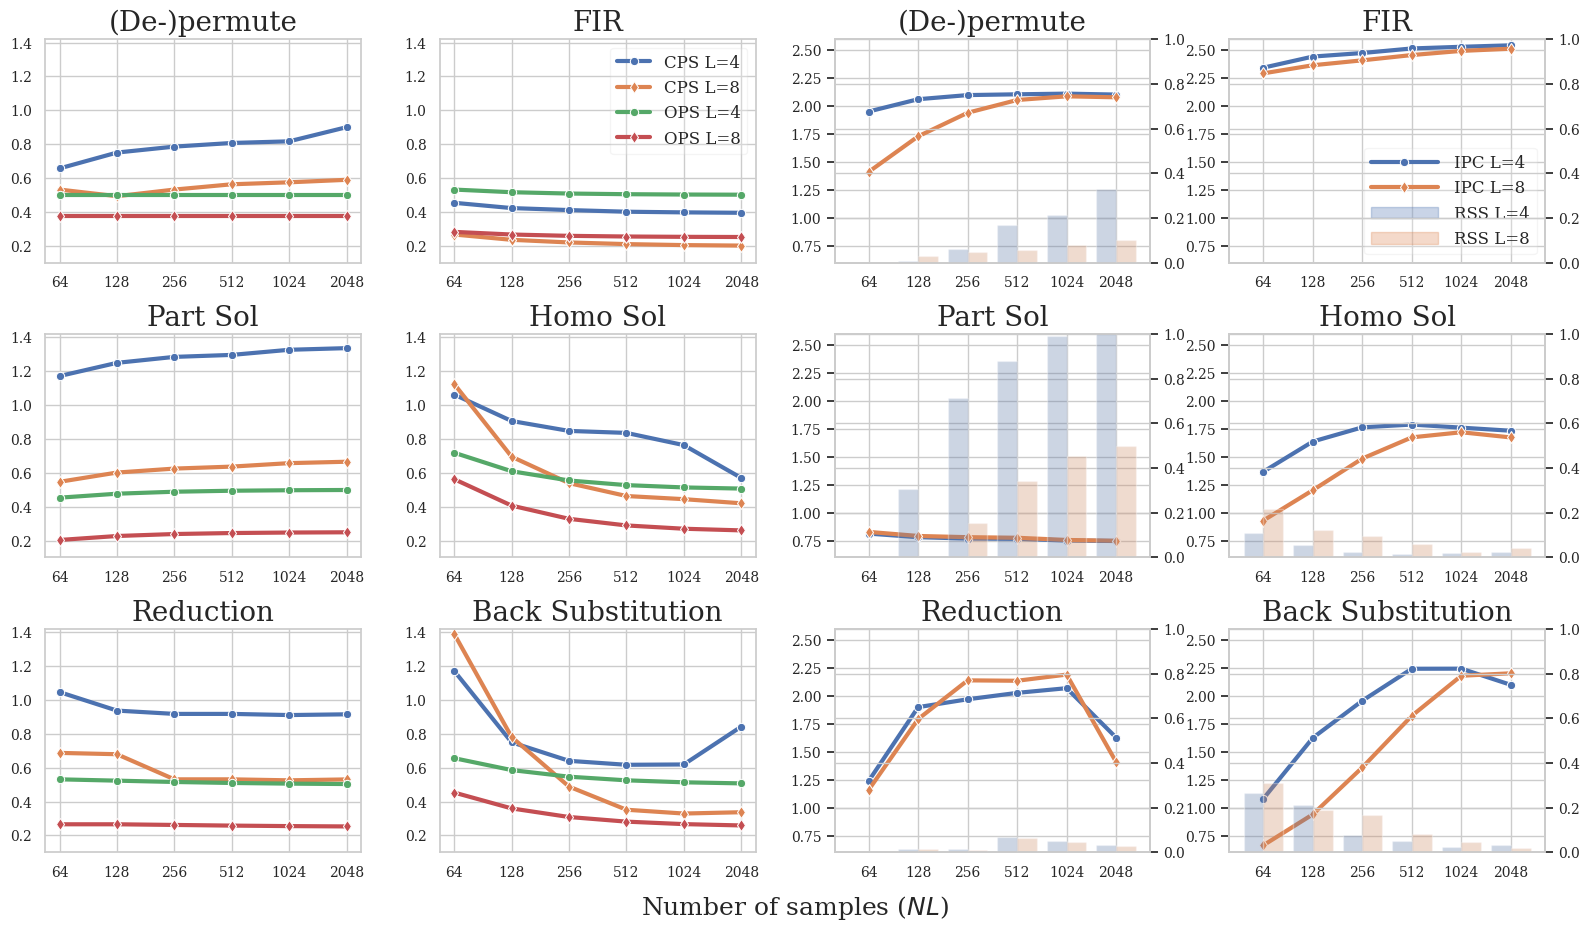

In [75]:
# Set seaborn style and font properties
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 20,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 12
})

default_palette = sns.color_palette()
blue = default_palette[0]    # Default blue (first color)
orange = default_palette[1]  # Default orange (second color)
green = default_palette[2]    # Default blue (first color)
red = default_palette[3]  # Default orange (second color)

# Create 6x2 subplot layout
fig, ((ax1, ax3,ax2, ax4), (ax5, ax7,ax6, ax8), (ax9, ax11,ax10, ax12)) = plt.subplots(3, 4, figsize=(16, 9))
x = np.arange(len(N))

# First row, first subplot: PM CPS and OPS comparison
sns.lineplot(x=x, y=pm_cps4, marker='o', label='CPS L=4', linewidth=3, ax=ax1,markersize=6, legend=False)
sns.lineplot(x=x, y=pm_cps8[:-1], marker='d', label='CPS L=8', linewidth=3, ax=ax1, legend=False)
sns.lineplot(x=x, y=pm_ops4, marker='o', label='OPS L=4', linewidth=3, ax=ax1, legend=False)
sns.lineplot(x=x, y=pm_ops8, marker='d', label='OPS L=8', linewidth=3, ax=ax1, legend=False)
ax1.set_xticks(x)
ax1.set_xticklabels(N)
ax1.set_ylim(0.1,1.42)
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_title('(De-)permute')
# legend1 = ax1.legend(framealpha=0.9, fontsize=8)
# legend1.get_frame().set_alpha(0.2)
# for text in legend1.get_texts():
#     text.set_fontweight('bold')

# First row, second subplot: PM IPC and RSS comparison
ax2_twin = ax2.twinx()
ax2_twin.set_ylim(0, 1)
rss_data_pm = pd.DataFrame({
    'x': list(x) + list(x),
    'rss': list(pm_rss4) + list(pm_rss8[:-1]),
    'type': ['Vec4f'] * len(x) + ['Vec8f'] * len(x)
})
sns.barplot(data=rss_data_pm, x='x', y='rss', hue='type', alpha=0.3, ax=ax2_twin, 
           palette={'Vec4f': blue, 'Vec8f': orange}, legend=False)
sns.lineplot(x=x, y=pm_ipc4, marker='o', label='IPC L=4', linewidth=3, ax=ax2, legend=False)
sns.lineplot(x=x, y=pm_ipc8[:-1], marker='d', label='IPC L=8', linewidth=3, ax=ax2, legend=False)
ax2.set_xticks(x)
ax2.set_xticklabels(N)
ax2.set_ylim(0.6,2.6)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2_twin.set_ylabel('')
ax2.tick_params(axis='y')
ax2_twin.tick_params(axis='y')
ax2.grid(True, which='both')
ax2.set_title('(De-)permute')
# handles2, labels2 = ax2.get_legend_handles_labels()
# rss_vec4f_patch = mpatches.Patch(color=blue, alpha=0.3, label='RSS L=4')
# rss_vec8f_patch = mpatches.Patch(color=orange, alpha=0.3, label='RSS L=8')
# handles3 = [rss_vec4f_patch, rss_vec8f_patch]
# labels3 = ['RSS L=4', 'RSS L=8']
# legend2 = ax2.legend(handles2 + handles3, labels2 + labels3, 
#                    handlelength=4, handletextpad=1.0, framealpha=0.9, fontsize=8,loc='lower left')
# legend2.get_frame().set_alpha(0.2)
# for text in legend2.get_texts():
#     text.set_fontweight('bold')

# Second row, first subplot: FIR CPS and OPS comparison
sns.lineplot(x=x, y=fir_cps4, marker='o', label='CPS L=4', linewidth=3, ax=ax3, legend=False)
sns.lineplot(x=x, y=fir_cps8[:-1], marker='d', label='CPS L=8', linewidth=3, ax=ax3, legend=False)
sns.lineplot(x=x, y=fir_ops4, marker='o', label='OPS L=4', linewidth=3, ax=ax3, legend=False)
sns.lineplot(x=x, y=fir_ops8, marker='d', label='OPS L=8', linewidth=3, ax=ax3, legend=False)
ax3.set_xticks(x)
ax3.set_xticklabels(N)
ax3.set_ylim(0.1,1.42)
ax3.set_xlabel('')
ax3.set_ylabel('')
ax3.set_title('FIR')
legend3 = ax3.legend(framealpha=0.9)
legend3.get_frame().set_alpha(0.2)
# for text in legend3.get_texts():
#     text.set_fontweight('bold')

# Second row, second subplot: FIR IPC and RSS comparison
ax4_twin = ax4.twinx()
ax4_twin.set_ylim(0, 1)
rss_data_fir = pd.DataFrame({
    'x': list(x) + list(x),
    'rss': list(fir_rss4) + list(fir_rss8[:-1]),
    'type': ['Vec4f'] * len(x) + ['Vec8f'] * len(x)
})
sns.barplot(data=rss_data_fir, x='x', y='rss', hue='type', alpha=0.3, ax=ax4_twin, 
           palette={'Vec4f': blue, 'Vec8f': orange}, legend=False)
sns.lineplot(x=x, y=fir_ipc4, marker='o', label='IPC L=4', linewidth=3, ax=ax4)
sns.lineplot(x=x, y=fir_ipc8[:-1], marker='d', label='IPC L=8', linewidth=3, ax=ax4)
ax4.set_xticks(x)
ax4.set_xticklabels(N)
ax4.set_ylim(0.6,2.6)
ax4.set_xlabel('')
ax4.set_ylabel('')
ax4_twin.set_ylabel('')
ax4.tick_params(axis='y')
ax4_twin.tick_params(axis='y')
ax4.grid(True, which='both')
ax4.set_title('FIR')
handles4, labels4 = ax4.get_legend_handles_labels()
rss_vec4f_patch_fir = mpatches.Patch(color=blue, alpha=0.3, label='RSS L=4')
rss_vec8f_patch_fir = mpatches.Patch(color=orange, alpha=0.3, label='RSS L=8')
handles4_3 = [rss_vec4f_patch_fir, rss_vec8f_patch_fir]
labels4_3 = ['RSS L=4', 'RSS L=8']
legend4 = ax4.legend(handles4 + handles4_3, labels4 + labels4_3, 
                   handlelength=4, handletextpad=1.0, framealpha=0.9,loc='lower right')
legend4.get_frame().set_alpha(0.2)
# for text in legend4.get_texts():
#     text.set_fontweight('bold')

# Third row, first subplot: PS CPS and OPS comparison
sns.lineplot(x=x, y=ps_cps4, marker='o', label='CPS L=4', linewidth=3, ax=ax5, legend=False)
sns.lineplot(x=x, y=ps_cps8[:-1], marker='d', label='CPS L=8', linewidth=3, ax=ax5, legend=False)
sns.lineplot(x=x, y=ps_ops4, marker='o', label='OPS L=4', linewidth=3, ax=ax5, legend=False)
sns.lineplot(x=x, y=ps_ops8, marker='d', label='OPS L=8', linewidth=3, ax=ax5, legend=False)
ax5.set_xticks(x)
ax5.set_xticklabels(N)
ax5.set_ylim(0.1,1.42)
ax5.set_xlabel('')
ax5.set_ylabel('')
ax5.set_title('Part Sol')
# legend5 = ax5.legend(framealpha=0.9, fontsize=8,loc='upper right')
# legend5.get_frame().set_alpha(0.2)
# for text in legend5.get_texts():
#     text.set_fontweight('bold')

# Third row, second subplot: PS IPC and RSS comparison
ax6_twin = ax6.twinx()
ax6_twin.set_ylim(0, 1)
rss_data_ps = pd.DataFrame({
    'x': list(x) + list(x),
    'rss': list(ps_rss4) + list(ps_rss8[:-1]),
    'type': ['Vec4f'] * len(x) + ['Vec8f'] * len(x)
})
sns.barplot(data=rss_data_ps, x='x', y='rss', hue='type', alpha=0.3, ax=ax6_twin, 
           palette={'Vec4f': blue, 'Vec8f': orange}, legend=False)
sns.lineplot(x=x, y=ps_ipc4, marker='o', label='IPC L=4', linewidth=3, ax=ax6, legend=False)
sns.lineplot(x=x, y=ps_ipc8[:-1], marker='d', label='IPC L=8', linewidth=3, ax=ax6, legend=False)
ax6.set_xticks(x)
ax6.set_xticklabels(N)
ax6.set_ylim(0.6,2.6)
ax6.set_xlabel('')
ax6.set_ylabel('')
ax6_twin.set_ylabel('')
ax6.tick_params(axis='y')
ax6_twin.tick_params(axis='y')
ax6.grid(True, which='both')
ax6.set_title('Part Sol')
# handles6, labels6 = ax6.get_legend_handles_labels()
# rss_vec4f_patch_ps = mpatches.Patch(color=blue, alpha=0.3, label='RSS L=4')
# rss_vec8f_patch_ps = mpatches.Patch(color=orange, alpha=0.3, label='RSS L=8')
# handles6_3 = [rss_vec4f_patch_ps, rss_vec8f_patch_ps]
# labels6_3 = ['RSS L=4', 'RSS L=8']
# legend6 = ax6.legend(handles6 + handles6_3, labels6 + labels6_3, 
#                    handlelength=4, handletextpad=1.0, framealpha=0.9, fontsize=8,loc='upper left')
# legend6.get_frame().set_alpha(0.2)
# for text in legend6.get_texts():
#     text.set_fontweight('bold')

# Fourth row, first subplot: HS CPS and OPS comparison
sns.lineplot(x=x, y=hs_cps4, marker='o', label='CPS L=4', linewidth=3, ax=ax7, legend=False)
sns.lineplot(x=x, y=hs_cps8[:-1], marker='d', label='CPS L=8', linewidth=3, ax=ax7, legend=False)
sns.lineplot(x=x, y=hs_ops4, marker='o', label='OPS L=4', linewidth=3, ax=ax7, legend=False)
sns.lineplot(x=x, y=hs_ops8, marker='d', label='OPS L=8', linewidth=3, ax=ax7, legend=False)
ax7.set_xticks(x)
ax7.set_xticklabels(N)
ax7.set_ylim(0.1,1.42)
ax7.set_xlabel('')
ax7.set_ylabel('')
ax7.set_title('Homo Sol')
# legend7 = ax7.legend(framealpha=0.9, fontsize=8)
# legend7.get_frame().set_alpha(0.2)
# for text in legend7.get_texts():
#     text.set_fontweight('bold')

# Fourth row, second subplot: HS IPC and RSS comparison
ax8_twin = ax8.twinx()
ax8_twin.set_ylim(0, 1)
rss_data_hs = pd.DataFrame({
    'x': list(x) + list(x),
    'rss': list(hs_rss4) + list(hs_rss8[:-1]),
    'type': ['Vec4f'] * len(x) + ['Vec8f'] * len(x)
})
sns.barplot(data=rss_data_hs, x='x', y='rss', hue='type', alpha=0.3, ax=ax8_twin, 
           palette={'Vec4f': blue, 'Vec8f': orange}, legend=False)
sns.lineplot(x=x, y=hs_ipc4, marker='o', label='IPC L=4', linewidth=3, ax=ax8, legend=False)
sns.lineplot(x=x, y=hs_ipc8[:-1], marker='d', label='IPC L=8', linewidth=3, ax=ax8, legend=False)
ax8.set_xticks(x)
ax8.set_xticklabels(N)
ax8.set_ylim(0.6,2.6)
ax8.set_xlabel('')
ax8.set_ylabel('')
ax8_twin.set_ylabel('')
ax8.tick_params(axis='y')
ax8_twin.tick_params(axis='y')
ax8.grid(True, which='both')
ax8.set_title('Homo Sol')
# handles8, labels8 = ax8.get_legend_handles_labels()
# rss_vec4f_patch_hs = mpatches.Patch(color=blue, alpha=0.3, label='RSS L=4')
# rss_vec8f_patch_hs = mpatches.Patch(color=orange, alpha=0.3, label='RSS L=8')
# handles8_3 = [rss_vec4f_patch_hs, rss_vec8f_patch_hs]
# labels8_3 = ['RSS L=4', 'RSS L=8']
# legend8 = ax8.legend(handles8 + handles8_3, labels8 + labels8_3, 
#                    handlelength=4, handletextpad=1.0, framealpha=0.9, fontsize=8,loc='lower right')
# legend8.get_frame().set_alpha(0.2)
# for text in legend8.get_texts():
#     text.set_fontweight('bold')

# Fifth row, first subplot: CRF CPS and OPS comparison
sns.lineplot(x=x, y=crf_cps4, marker='o', label='CPS L=4', linewidth=3, ax=ax9, legend=False)
sns.lineplot(x=x, y=crf_cps8[:-1], marker='d', label='CPS L=8', linewidth=3, ax=ax9, legend=False)
sns.lineplot(x=x, y=crf_ops4, marker='o', label='OPS L=4', linewidth=3, ax=ax9, legend=False)
sns.lineplot(x=x, y=crf_ops8, marker='d', label='OPS L=8', linewidth=3, ax=ax9, legend=False)
ax9.set_xticks(x)
ax9.set_xticklabels(N)
ax9.set_ylim(0.1,1.42)
ax9.set_xlabel('')
ax9.set_ylabel('')
ax9.set_title('Reduction')
# legend9 = ax9.legend(framealpha=0.9, fontsize=8,loc='upper right')
# legend9.get_frame().set_alpha(0.2)
# for text in legend9.get_texts():
#     text.set_fontweight('bold')

# Fifth row, second subplot: CRF IPC and RSS comparison
ax10_twin = ax10.twinx()
ax10_twin.set_ylim(0, 1)
rss_data_crf = pd.DataFrame({
    'x': list(x) + list(x),
    'rss': list(crf_rss4) + list(crf_rss8[:-1]),
    'type': ['Vec4f'] * len(x) + ['Vec8f'] * len(x)
})
sns.barplot(data=rss_data_crf, x='x', y='rss', hue='type', alpha=0.3, ax=ax10_twin, 
           palette={'Vec4f': blue, 'Vec8f': orange}, legend=False)
sns.lineplot(x=x, y=crf_ipc4, marker='o', label='IPC L=4', linewidth=3, ax=ax10, legend=False)
sns.lineplot(x=x, y=crf_ipc8[:-1], marker='d', label='IPC L=8', linewidth=3, ax=ax10, legend=False)
ax10.set_xticks(x)
ax10.set_xticklabels(N)
ax10.set_ylim(0.6,2.6)
ax10.set_xlabel('')
ax10.set_ylabel('')
ax10_twin.set_ylabel('')
ax10.tick_params(axis='y')
ax10_twin.tick_params(axis='y')
ax10.grid(True, which='both')
ax10.set_title('Reduction')
# handles10, labels10 = ax10.get_legend_handles_labels()
# rss_vec4f_patch_crf = mpatches.Patch(color=blue, alpha=0.3, label='RSS L=4')
# rss_vec8f_patch_crf = mpatches.Patch(color=orange, alpha=0.3, label='RSS L=8')
# handles10_3 = [rss_vec4f_patch_crf, rss_vec8f_patch_crf]
# labels10_3 = ['RSS L=4', 'RSS L=8']
# legend10 = ax10.legend(handles10 + handles10_3, labels10 + labels10_3, 
#                      handlelength=4, handletextpad=1.0, framealpha=0.9, fontsize=8,loc='lower center')
# legend10.get_frame().set_alpha(0.2)
# for text in legend10.get_texts():
#     text.set_fontweight('bold')

# Sixth row, first subplot: CRB CPS and OPS comparison
sns.lineplot(x=x, y=crb_cps4, marker='o', label='CPS L=4', linewidth=3, ax=ax11, legend=False)
sns.lineplot(x=x, y=crb_cps8[:-1], marker='d', label='CPS L=8', linewidth=3, ax=ax11, legend=False)
sns.lineplot(x=x, y=crb_ops4, marker='o', label='OPS L=4', linewidth=3, ax=ax11, legend=False)
sns.lineplot(x=x, y=crb_ops8, marker='d', label='OPS L=8', linewidth=3, ax=ax11, legend=False)
ax11.set_xticks(x)
ax11.set_xticklabels(N)
ax11.set_ylim(0.1,1.42)
ax11.set_xlabel('')
ax11.set_ylabel('')
ax11.set_title('Back Substitution')
# legend11 = ax11.legend(framealpha=0.9, fontsize=8)
# legend11.get_frame().set_alpha(0.2)
# for text in legend11.get_texts():
#     text.set_fontweight('bold')

# Sixth row, second subplot: CRB IPC and RSS comparison
ax12_twin = ax12.twinx()
ax12_twin.set_ylim(0, 1)
rss_data_crb = pd.DataFrame({
    'x': list(x) + list(x),
    'rss': list(crb_rss4) + list(crb_rss8[:-1]),
    'type': ['Vec4f'] * len(x) + ['Vec8f'] * len(x)
})
sns.barplot(data=rss_data_crb, x='x', y='rss', hue='type', alpha=0.3, ax=ax12_twin, 
           palette={'Vec4f': blue, 'Vec8f': orange}, legend=False)
sns.lineplot(x=x, y=crb_ipc4, marker='o', label='IPC L=4', linewidth=3, ax=ax12, legend=False)
sns.lineplot(x=x, y=crb_ipc8[:-1], marker='d', label='IPC L=8', linewidth=3, ax=ax12, legend=False)
ax12.set_xticks(x)
ax12.set_xticklabels(N)
ax12.set_ylim(0.6,2.6)
ax12.set_xlabel('')
ax12.set_ylabel('')
ax12_twin.set_ylabel('')
ax12.tick_params(axis='y')
ax12_twin.tick_params(axis='y')
ax12.grid(True, which='both')
ax12.set_title('Back Substitution')
# handles12, labels12 = ax12.get_legend_handles_labels()
# rss_vec4f_patch_crb = mpatches.Patch(color=blue, alpha=0.3, label='RSS L=4')
# rss_vec8f_patch_crb = mpatches.Patch(color=orange, alpha=0.3, label='RSS L=8')
# handles12_3 = [rss_vec4f_patch_crb, rss_vec8f_patch_crb]
# labels12_3 = ['RSS L=4', 'RSS L=8']
# legend12 = ax12.legend(handles12 + handles12_3, labels12 + labels12_3, 
#                      handlelength=4, handletextpad=1.0, framealpha=0.9, fontsize=8,loc='lower right')
# legend12.get_frame().set_alpha(0.2)
# for text in legend12.get_texts():
#     text.set_fontweight('bold')

plt.tight_layout()
plt.subplots_adjust(wspace=0.25)  # Values typically 0.1-0.3
# fig.text(0.5, -0.02, 'Function Size (NL)', ha='center',  va='bottom',fontsize=14)

# # Common title for column 1 (Performance Rate)
# fig.text(0.24, 1, 'Performance Rate', ha='center', va='bottom', 
#          fontsize=14)

# # Common title for column 2 (Pipeline Efficiency)  
# fig.text(0.75, 1, 'Pipeline Efficiency', ha='center', va='bottom',
#          fontsize=14)

# # Common title for column 1 (Performance Rate)
# fig.text(0.49, 0.17, 'IPC', rotation=90, ha='center', va='bottom', 
#          fontsize=12)

# fig.text(0.49, 0.5, 'IPC', rotation=90, ha='center', va='bottom', 
#          fontsize=12)

# fig.text(0.49, 0.83, 'IPC', rotation=90, ha='center', va='bottom', 
#          fontsize=12)

# # # Common title for column 2 (Pipeline Efficiency)  
# fig.text(0.999, 0.17, 'RSS', rotation=90, ha='center', va='bottom', 
#          fontsize=12)

# fig.text(0.999, 0.5, 'RSS', rotation=90, ha='center', va='bottom', 
#          fontsize=12)

# fig.text(0.999, 0.83, 'RSS', rotation=90, ha='center', va='bottom', 
#          fontsize=12)

fig.text(0.5, -0.015, 'Number of samples ($NL$)', ha='center', va='center', fontsize=18)

# plt.savefig('function_performance.png') 
# plt.savefig('plot1.png', bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none')
# plt.savefig('plot1.png', bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none')
plt.show()

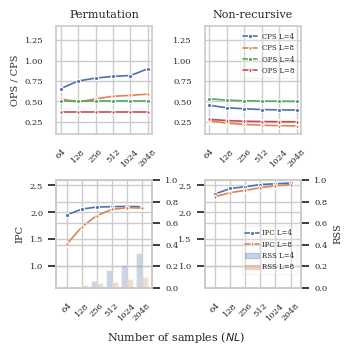

In [ ]:
# Set seaborn style and font properties
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 6,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5
})

default_palette = sns.color_palette()
blue = default_palette[0]
orange = default_palette[1]
green = default_palette[2]
red = default_palette[3]

# Create 2x2 subplot layout — IEEE single column = 3.5 in wide
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(3.5, 3.3))
x = np.arange(len(N))

# ===================== Top-left: Permute CPS/OPS =====================
sns.lineplot(x=x, y=pm_cps4, marker='o', label='CPS L=4', linewidth=1.2, ax=ax1, markersize=3, legend=False)
sns.lineplot(x=x, y=pm_cps8[:-1], marker='d', label='CPS L=8', linewidth=1.2, ax=ax1, markersize=3, legend=False)
sns.lineplot(x=x, y=pm_ops4, marker='o', label='OPS L=4', linewidth=1.2, ax=ax1, markersize=3, legend=False)
sns.lineplot(x=x, y=pm_ops8, marker='d', label='OPS L=8', linewidth=1.2, ax=ax1, markersize=3, legend=False)
ax1.set_xticks(x)
ax1.set_xticklabels(N, rotation=45, ha='center')
ax1.set_ylim(0.1, 1.42)
ax1.set_xlabel('')
ax1.set_ylabel('OPS / CPS')
ax1.set_title('Permutation')

# ===================== Top-right: FIR CPS/OPS =====================
sns.lineplot(x=x, y=fir_cps4, marker='o', label='CPS L=4', linewidth=1.2, ax=ax2, markersize=3, legend=False)
sns.lineplot(x=x, y=fir_cps8[:-1], marker='d', label='CPS L=8', linewidth=1.2, ax=ax2, markersize=3, legend=False)
sns.lineplot(x=x, y=fir_ops4, marker='o', label='OPS L=4', linewidth=1.2, ax=ax2, markersize=3, legend=False)
sns.lineplot(x=x, y=fir_ops8, marker='d', label='OPS L=8', linewidth=1.2, ax=ax2, markersize=3, legend=False)
ax2.set_xticks(x)
ax2.set_xticklabels(N, rotation=45, ha='center')
ax2.set_ylim(0.1, 1.42)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_title('Non-recursive')
ax2.legend(framealpha=0.2, loc='upper right')

# ===================== Bottom-left: Permute IPC/RSS =====================
ax3_twin = ax3.twinx()
ax3_twin.set_ylim(0, 1)
rss_data_pm = pd.DataFrame({
    'x': list(x) + list(x),
    'rss': list(pm_rss4) + list(pm_rss8[:-1]),
    'type': ['Vec4f'] * len(x) + ['Vec8f'] * len(x)
})
sns.barplot(data=rss_data_pm, x='x', y='rss', hue='type', alpha=0.3, ax=ax3_twin,
            palette={'Vec4f': blue, 'Vec8f': orange}, legend=False)
sns.lineplot(x=x, y=pm_ipc4, marker='o', label='IPC L=4', linewidth=1.2, ax=ax3, markersize=3, legend=False)
sns.lineplot(x=x, y=pm_ipc8[:-1], marker='d', label='IPC L=8', linewidth=1.2, ax=ax3, markersize=3, legend=False)
ax3.set_xticks(x)
ax3.set_xticklabels(N, rotation=45, ha='center')
ax3.set_ylim(0.6, 2.6)
ax3.set_xlabel('')
ax3.set_ylabel('IPC')
ax3_twin.set_ylabel('')
ax3.tick_params(axis='y')
ax3_twin.tick_params(axis='y')
ax3.grid(True, which='both')

# ===================== Bottom-right: FIR IPC/RSS =====================
ax4_twin = ax4.twinx()
ax4_twin.set_ylim(0, 1)
rss_data_fir = pd.DataFrame({
    'x': list(x) + list(x),
    'rss': list(fir_rss4) + list(fir_rss8[:-1]),
    'type': ['Vec4f'] * len(x) + ['Vec8f'] * len(x)
})
sns.barplot(data=rss_data_fir, x='x', y='rss', hue='type', alpha=0.3, ax=ax4_twin,
            palette={'Vec4f': blue, 'Vec8f': orange}, legend=False)
sns.lineplot(x=x, y=fir_ipc4, marker='o', label='IPC L=4', linewidth=1.2, ax=ax4, markersize=3, legend=False)
sns.lineplot(x=x, y=fir_ipc8[:-1], marker='d', label='IPC L=8', linewidth=1.2, ax=ax4, markersize=3, legend=False)
ax4.set_xticks(x)
ax4.set_xticklabels(N, rotation=45, ha='center')
ax4.set_ylim(0.6, 2.6)
ax4.set_xlabel('')
ax4.set_ylabel('')
ax4_twin.set_ylabel('RSS')
ax4.tick_params(axis='y')
ax4_twin.tick_params(axis='y')
ax4.grid(True, which='both')

# Legend on ax4_twin (topmost layer, renders above grid)
handles4, labels4 = ax4.get_legend_handles_labels()
rss_vec4f_patch = mpatches.Patch(color=blue, alpha=0.3, label='RSS L=4')
rss_vec8f_patch = mpatches.Patch(color=orange, alpha=0.3, label='RSS L=8')
ax4_twin.legend(handles4 + [rss_vec4f_patch, rss_vec8f_patch],
                labels4 + ['RSS L=4', 'RSS L=8'],
                handlelength=2, handletextpad=0.5, framealpha=0.2,
                loc='right', bbox_to_anchor=(1.0, 0.35))

plt.tight_layout()
plt.subplots_adjust(wspace=0.55)

fig.text(0.5, -0.02, 'Number of samples ($NL$)', ha='center', va='center', fontsize=8)

plt.savefig('../plot/pm_fir_22.png', bbox_inches='tight', dpi=600, facecolor='white', edgecolor='none')
plt.show()

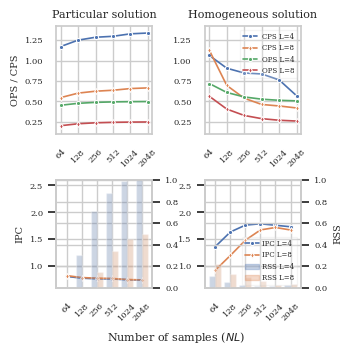

In [ ]:
# Set seaborn style and font properties
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 6,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5
})

default_palette = sns.color_palette()
blue = default_palette[0]
orange = default_palette[1]
green = default_palette[2]
red = default_palette[3]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(3.5, 3.3))
x = np.arange(len(N))

# ===================== Top-left: Part Sol CPS/OPS =====================
sns.lineplot(x=x, y=ps_cps4, marker='o', label='CPS L=4', linewidth=1.2, ax=ax1, markersize=3, legend=False)
sns.lineplot(x=x, y=ps_cps8[:-1], marker='d', label='CPS L=8', linewidth=1.2, ax=ax1, markersize=3, legend=False)
sns.lineplot(x=x, y=ps_ops4, marker='o', label='OPS L=4', linewidth=1.2, ax=ax1, markersize=3, legend=False)
sns.lineplot(x=x, y=ps_ops8, marker='d', label='OPS L=8', linewidth=1.2, ax=ax1, markersize=3, legend=False)
ax1.set_xticks(x)
ax1.set_xticklabels(N, rotation=45, ha='center')
ax1.set_ylim(0.1, 1.42)
ax1.set_xlabel('')
ax1.set_ylabel('OPS / CPS')
ax1.set_title('Particular solution')

# ===================== Top-right: Homo Sol CPS/OPS =====================
sns.lineplot(x=x, y=hs_cps4, marker='o', label='CPS L=4', linewidth=1.2, ax=ax2, markersize=3, legend=False)
sns.lineplot(x=x, y=hs_cps8[:-1], marker='d', label='CPS L=8', linewidth=1.2, ax=ax2, markersize=3, legend=False)
sns.lineplot(x=x, y=hs_ops4, marker='o', label='OPS L=4', linewidth=1.2, ax=ax2, markersize=3, legend=False)
sns.lineplot(x=x, y=hs_ops8, marker='d', label='OPS L=8', linewidth=1.2, ax=ax2, markersize=3, legend=False)
ax2.set_xticks(x)
ax2.set_xticklabels(N, rotation=45, ha='center')
ax2.set_ylim(0.1, 1.42)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_title('Homogeneous solution')
ax2.legend(framealpha=0.2, loc='upper right')

# ===================== Bottom-left: Part Sol IPC/RSS =====================
ax3_twin = ax3.twinx()
ax3_twin.set_ylim(0, 1)
rss_data_ps = pd.DataFrame({
    'x': list(x) + list(x),
    'rss': list(ps_rss4) + list(ps_rss8[:-1]),
    'type': ['Vec4f'] * len(x) + ['Vec8f'] * len(x)
})
sns.barplot(data=rss_data_ps, x='x', y='rss', hue='type', alpha=0.3, ax=ax3_twin,
            palette={'Vec4f': blue, 'Vec8f': orange}, legend=False)
sns.lineplot(x=x, y=ps_ipc4, marker='o', label='IPC L=4', linewidth=1.2, ax=ax3, markersize=3, legend=False)
sns.lineplot(x=x, y=ps_ipc8[:-1], marker='d', label='IPC L=8', linewidth=1.2, ax=ax3, markersize=3, legend=False)
ax3.set_xticks(x)
ax3.set_xticklabels(N, rotation=45, ha='center')
ax3.set_ylim(0.6, 2.6)
ax3.set_xlabel('')
ax3.set_ylabel('IPC')
ax3_twin.set_ylabel('')
ax3.tick_params(axis='y')
ax3_twin.tick_params(axis='y')
ax3.grid(True, which='both')

# ===================== Bottom-right: Homo Sol IPC/RSS =====================
ax4_twin = ax4.twinx()
ax4_twin.set_ylim(0, 1)
rss_data_hs = pd.DataFrame({
    'x': list(x) + list(x),
    'rss': list(hs_rss4) + list(hs_rss8[:-1]),
    'type': ['Vec4f'] * len(x) + ['Vec8f'] * len(x)
})
sns.barplot(data=rss_data_hs, x='x', y='rss', hue='type', alpha=0.3, ax=ax4_twin,
            palette={'Vec4f': blue, 'Vec8f': orange}, legend=False)
sns.lineplot(x=x, y=hs_ipc4, marker='o', label='IPC L=4', linewidth=1.2, ax=ax4, markersize=3, legend=False)
sns.lineplot(x=x, y=hs_ipc8[:-1], marker='d', label='IPC L=8', linewidth=1.2, ax=ax4, markersize=3, legend=False)
ax4.set_xticks(x)
ax4.set_xticklabels(N, rotation=45, ha='center')
ax4.set_ylim(0.6, 2.6)
ax4.set_xlabel('')
ax4.set_ylabel('')
ax4_twin.set_ylabel('RSS')
ax4.tick_params(axis='y')
ax4_twin.tick_params(axis='y')
ax4.grid(True, which='both')

handles4, labels4 = ax4.get_legend_handles_labels()
rss_vec4f_patch = mpatches.Patch(color=blue, alpha=0.3, label='RSS L=4')
rss_vec8f_patch = mpatches.Patch(color=orange, alpha=0.3, label='RSS L=8')
ax4_twin.legend(handles4 + [rss_vec4f_patch, rss_vec8f_patch],
                labels4 + ['RSS L=4', 'RSS L=8'],
                handlelength=2, handletextpad=0.5, framealpha=0.2,
                loc='right', bbox_to_anchor=(1.0, 0.25))

plt.tight_layout()
plt.subplots_adjust(wspace=0.55)
fig.text(0.5, -0.02, 'Number of samples ($NL$)', ha='center', va='center', fontsize=8)
plt.savefig('../plot/ph_22.png', bbox_inches='tight', dpi=600, facecolor='white', edgecolor='none')
plt.show()

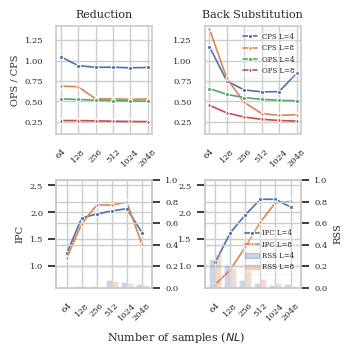

In [ ]:
# Set seaborn style and font properties
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 6,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5
})

default_palette = sns.color_palette()
blue = default_palette[0]
orange = default_palette[1]
green = default_palette[2]
red = default_palette[3]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(3.5, 3.3))
x = np.arange(len(N))

# ===================== Top-left: Reduction CPS/OPS =====================
sns.lineplot(x=x, y=crf_cps4, marker='o', label='CPS L=4', linewidth=1.2, ax=ax1, markersize=3, legend=False)
sns.lineplot(x=x, y=crf_cps8[:-1], marker='d', label='CPS L=8', linewidth=1.2, ax=ax1, markersize=3, legend=False)
sns.lineplot(x=x, y=crf_ops4, marker='o', label='OPS L=4', linewidth=1.2, ax=ax1, markersize=3, legend=False)
sns.lineplot(x=x, y=crf_ops8, marker='d', label='OPS L=8', linewidth=1.2, ax=ax1, markersize=3, legend=False)
ax1.set_xticks(x)
ax1.set_xticklabels(N, rotation=45, ha='center')
ax1.set_ylim(0.1, 1.42)
ax1.set_xlabel('')
ax1.set_ylabel('OPS / CPS')
ax1.set_title('Reduction')

# ===================== Top-right: Back Substitution CPS/OPS =====================
sns.lineplot(x=x, y=crb_cps4, marker='o', label='CPS L=4', linewidth=1.2, ax=ax2, markersize=3, legend=False)
sns.lineplot(x=x, y=crb_cps8[:-1], marker='d', label='CPS L=8', linewidth=1.2, ax=ax2, markersize=3, legend=False)
sns.lineplot(x=x, y=crb_ops4, marker='o', label='OPS L=4', linewidth=1.2, ax=ax2, markersize=3, legend=False)
sns.lineplot(x=x, y=crb_ops8, marker='d', label='OPS L=8', linewidth=1.2, ax=ax2, markersize=3, legend=False)
ax2.set_xticks(x)
ax2.set_xticklabels(N, rotation=45, ha='center')
ax2.set_ylim(0.1, 1.42)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_title('Back Substitution')
ax2.legend(framealpha=0.2, loc='upper right')

# ===================== Bottom-left: Reduction IPC/RSS =====================
ax3_twin = ax3.twinx()
ax3_twin.set_ylim(0, 1)
rss_data_crf = pd.DataFrame({
    'x': list(x) + list(x),
    'rss': list(crf_rss4) + list(crf_rss8[:-1]),
    'type': ['Vec4f'] * len(x) + ['Vec8f'] * len(x)
})
sns.barplot(data=rss_data_crf, x='x', y='rss', hue='type', alpha=0.3, ax=ax3_twin,
            palette={'Vec4f': blue, 'Vec8f': orange}, legend=False)
sns.lineplot(x=x, y=crf_ipc4, marker='o', label='IPC L=4', linewidth=1.2, ax=ax3, markersize=3, legend=False)
sns.lineplot(x=x, y=crf_ipc8[:-1], marker='d', label='IPC L=8', linewidth=1.2, ax=ax3, markersize=3, legend=False)
ax3.set_xticks(x)
ax3.set_xticklabels(N, rotation=45, ha='center')
ax3.set_ylim(0.6, 2.6)
ax3.set_xlabel('')
ax3.set_ylabel('IPC')
ax3_twin.set_ylabel('')
ax3.tick_params(axis='y')
ax3_twin.tick_params(axis='y')
ax3.grid(True, which='both')

# ===================== Bottom-right: Back Substitution IPC/RSS =====================
ax4_twin = ax4.twinx()
ax4_twin.set_ylim(0, 1)
rss_data_crb = pd.DataFrame({
    'x': list(x) + list(x),
    'rss': list(crb_rss4) + list(crb_rss8[:-1]),
    'type': ['Vec4f'] * len(x) + ['Vec8f'] * len(x)
})
sns.barplot(data=rss_data_crb, x='x', y='rss', hue='type', alpha=0.3, ax=ax4_twin,
            palette={'Vec4f': blue, 'Vec8f': orange}, legend=False)
sns.lineplot(x=x, y=crb_ipc4, marker='o', label='IPC L=4', linewidth=1.2, ax=ax4, markersize=3, legend=False)
sns.lineplot(x=x, y=crb_ipc8[:-1], marker='d', label='IPC L=8', linewidth=1.2, ax=ax4, markersize=3, legend=False)
ax4.set_xticks(x)
ax4.set_xticklabels(N, rotation=45, ha='center')
ax4.set_ylim(0.6, 2.6)
ax4.set_xlabel('')
ax4.set_ylabel('')
ax4_twin.set_ylabel('RSS')
ax4.tick_params(axis='y')
ax4_twin.tick_params(axis='y')
ax4.grid(True, which='both')

handles4, labels4 = ax4.get_legend_handles_labels()
rss_vec4f_patch = mpatches.Patch(color=blue, alpha=0.3, label='RSS L=4')
rss_vec8f_patch = mpatches.Patch(color=orange, alpha=0.3, label='RSS L=8')
ax4_twin.legend(handles4 + [rss_vec4f_patch, rss_vec8f_patch],
                labels4 + ['RSS L=4', 'RSS L=8'],
                handlelength=2, handletextpad=0.5, framealpha=0.2,
                loc='right', bbox_to_anchor=(1.0, 0.35))

plt.tight_layout()
plt.subplots_adjust(wspace=0.55)
fig.text(0.5, -0.02, 'Number of samples ($NL$)', ha='center', va='center', fontsize=8)
plt.savefig('../plot/cr_22.png', bbox_inches='tight', dpi=600, facecolor='white', edgecolor='none')
plt.show()